<!-- # Spatial Disorder & Localisation

Real-space analysis of lower polariton localisation in a 2-D
Gaussian-correlated disorder potential.

**Contents**
1. Single realisation — disorder landscape and lowest eigenmodes
2. Sigma sweep — effective interaction strength vs disorder amplitude
3. (Optional) Xi sweep — correlation-length dependence of IPR -->


In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from polaritons.real_space import (
	gaussian_correlated_disorder,
	lp_hamiltonian,
	solve_low_modes,
	normalize_mode,
	ipr,
	g_eff_lowest_mode,
)
from polaritons.io import save_result
from polaritons.parameters import DEFAULT_PARAMS

# ---------------------------------------------------------------------------
# Matplotlib style
# ---------------------------------------------------------------------------
CMAP_NAME = "magma"
CMAP = plt.get_cmap(CMAP_NAME)

plt.rcParams.update({
	'font.family': 'serif',
	'font.size': 13,
	'axes.labelsize': 14,
	'axes.titlesize': 14,
	'figure.titlesize': 16,
	'image.cmap': CMAP_NAME,
})

# ---------------------------------------------------------------------------
# Physical constants (SI, eV-based)
# ---------------------------------------------------------------------------
hbar = 6.582119569e-16   # eV·s
m0   = 5.685630e-12      # eV·s²/m²  (free electron rest mass)

# ---------------------------------------------------------------------------
# System parameters
# ---------------------------------------------------------------------------
N = 256                  # grid points per side
L = 40e-6                # system size (m)

M_lp = 1e-5 * m0         # LP effective mass
xi = 20e-9               # disorder correlation length (m)
g_lp = DEFAULT_PARAMS.g_ex / (4.0 * DEFAULT_PARAMS.N_qw)  # eV·m², resonant LP value
G_PLOT_SCALE = 1e18
G_PLOT_LABEL = r"$g_{\rm eff}$ (µeV·µm²)"

print(f"Grid: {N}×{N},  L={L*1e6:.0f} µm,  dx={L/N*1e9:.1f} nm")
print(f"M_lp = {M_lp:.3e} eV·s²/m²   xi = {xi*1e9:.0f} nm")
print(f"g_lp = {g_lp:.3e} eV·m²")


Grid: 128×128,  L=40 µm,  dx=312.5 nm
M_lp = 5.686e-17 eV·s²/m²   xi = 20 nm


## 1 — Single realisation

Visualise the disorder landscape and the three lowest polariton eigenmodes.


Mode  Energy (meV)    IPR           g_eff
  0       0.0465     1.3820e+09    1.3820e+09
  1       0.1148     1.6198e+09    1.6198e+09
  2       0.1167     1.5964e+09    1.5964e+09
  3       0.1860     1.3869e+09    1.3869e+09
  4       0.2301     1.5947e+09    1.5947e+09
  5       0.2324     1.5979e+09    1.5979e+09


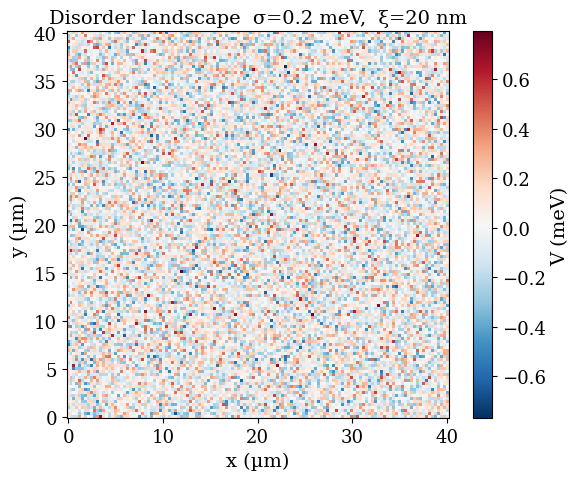

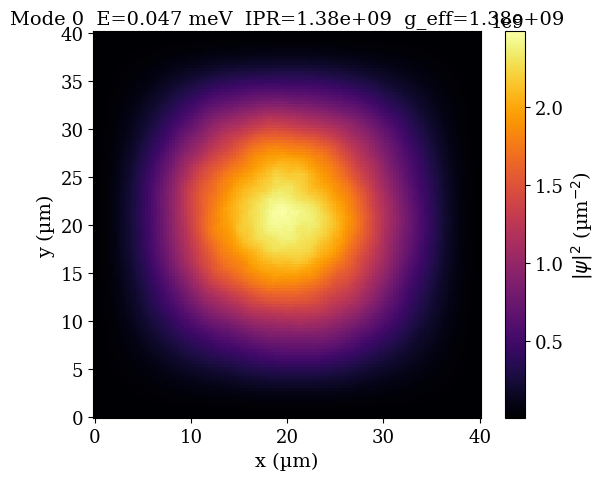

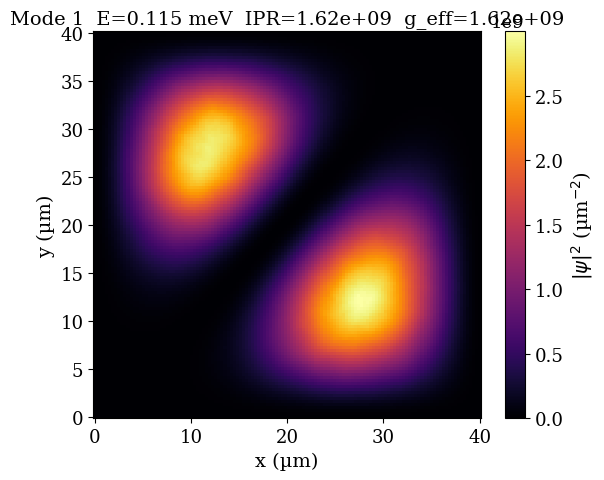

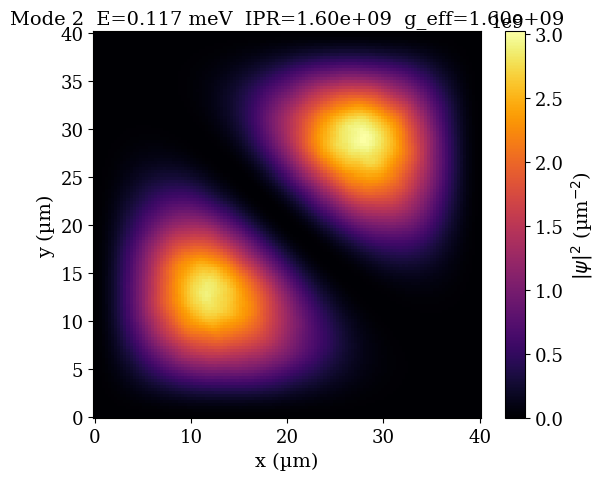

In [2]:
SEED = 1
sigma = 0.2e-3   # disorder amplitude (eV)
dx = L / N

# Generate disorder and solve for lowest modes
V = gaussian_correlated_disorder(N, L, sigma, xi, seed=SEED)
H = lp_hamiltonian(N, L, M_lp, V, hbar)
E, psi = solve_low_modes(H, n_modes=6)

modes = [normalize_mode(psi[:, n].reshape(N, N), dx) for n in range(psi.shape[1])]
iprs_ = [ipr(m, dx) for m in modes]
g_eff_ = [g_lp * v for v in iprs_]

print(f"Mode  Energy (meV)    IPR           {G_PLOT_LABEL}")
for n in range(len(modes)):
	print(f"  {n}   {1e3*E[n]:10.4f}     {iprs_[n]:.4e}    {G_PLOT_SCALE*g_eff_[n]:.4e}")

# Coordinate grid for plotting
x_um = np.linspace(0, L * 1e6, N)
X, Y = np.meshgrid(x_um, x_um, indexing="ij")

# --- Disorder landscape ---
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(X, Y, 1e3 * V, shading="auto", cmap=CMAP_NAME)
plt.colorbar(im, ax=ax, label="V (meV)")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title(f"Disorder landscape  σ={sigma*1e3:.1f} meV,  ξ={xi*1e9:.0f} nm")
plt.tight_layout()
plt.show()

# --- Lowest three eigenmodes ---
for n in range(3):
	fig, ax = plt.subplots(figsize=(6, 5))
	im = ax.pcolormesh(X, Y, np.abs(modes[n])**2, shading="auto", cmap=CMAP_NAME)
	plt.colorbar(im, ax=ax, label=r"$|\psi|^2$ (m$^{-2}$)")
	ax.set_xlabel("x (µm)")
	ax.set_ylabel("y (µm)")
	ax.set_title(
		f"Mode {n}  E={1e3*E[n]:.3f} meV  "
		f"IPR={iprs_[n]:.2e}  g_eff={G_PLOT_SCALE*g_eff_[n]:.2e}"
	)
	plt.tight_layout()
	plt.show()


## 2 — Sigma sweep

Average `g_eff` of the ground mode over multiple disorder realisations
as a function of disorder amplitude σ.  Results are saved to `Results/`.


  σ= 0.00 meV  →  g_eff = 1.3845e+09 ± 7.0108e-05
  σ= 0.02 meV  →  g_eff = 1.3847e+09 ± 3.6207e+06
  σ= 0.05 meV  →  g_eff = 1.3853e+09 ± 8.9897e+06
  σ= 0.10 meV  →  g_eff = 1.3868e+09 ± 1.7787e+07
  σ= 0.20 meV  →  g_eff = 1.3920e+09 ± 3.4916e+07
  σ= 0.50 meV  →  g_eff = 1.4244e+09 ± 8.4881e+07
  σ= 1.00 meV  →  g_eff = 1.5357e+09 ± 1.7450e+08
Saved  geff_sigma_3215e9.npy  [3, 7] float64


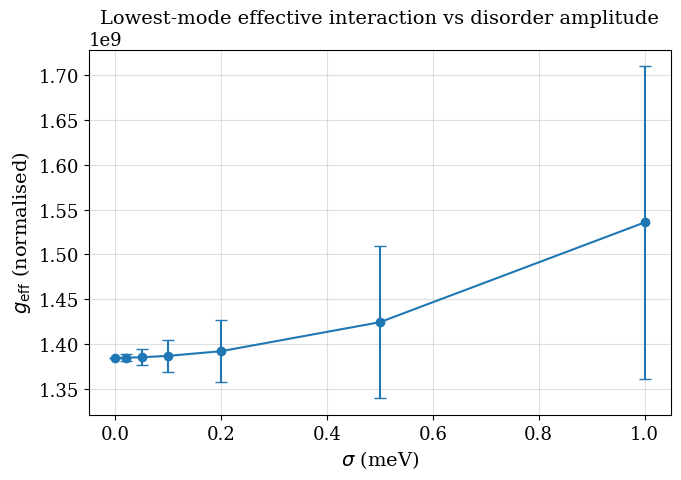

In [3]:
from polaritons.io import save_result, make_sweep_stem
from polaritons.parameters import DEFAULT_PARAMS

# ---------------------------------------------------------------------------
# Sweep configuration
# ---------------------------------------------------------------------------
sigmas = np.array([0.0, 0.02e-3, 0.05e-3, 0.1e-3, 0.2e-3, 0.5e-3, 1.0e-3])  # eV
n_realisations = 20

# ---------------------------------------------------------------------------
# Compute
# ---------------------------------------------------------------------------
g_mean = np.zeros(len(sigmas))
g_std = np.zeros(len(sigmas))

for si, s in enumerate(sigmas):
	vals = [
		g_eff_lowest_mode(N, L, M_lp, s, xi, hbar, g_lp=g_lp, seed=seed)
		for seed in range(n_realisations)
	]
	g_mean[si] = np.mean(vals)
	g_std[si] = np.std(vals)
	print(f"  σ={s*1e3:5.2f} meV  →  g_eff = {G_PLOT_SCALE*g_mean[si]:.4e} ± {G_PLOT_SCALE*g_std[si]:.4e}")

# ---------------------------------------------------------------------------
# Save results
# ---------------------------------------------------------------------------
result_array = np.vstack([sigmas, g_mean, g_std])   # shape (3, len(sigmas))

extra_meta = {
	"rows"           : ["sigma_eV", "g_mean_eV", "g_std_eV"],
	"N"              : N,
	"L_m"            : L,
	"M_lp_eVs2m2"   : M_lp,
	"xi_m"           : xi,
	"g_lp_eVm2"      : g_lp,
	"plot_scale"     : G_PLOT_SCALE,
	"plot_units"     : "µeV·µm²",
	"n_realisations" : n_realisations,
	"hbar_eVs"       : hbar,
}
stem = make_sweep_stem("geff_sigma", DEFAULT_PARAMS, extra={"xi": xi, "N": N})
save_result(result_array, "Results/interaction_strengths", stem, DEFAULT_PARAMS, extra_meta)

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(1e3 * sigmas, G_PLOT_SCALE * g_mean, yerr=G_PLOT_SCALE * g_std,
			marker='o', capsize=4, linewidth=1.5,
			color=CMAP(0.72), markerfacecolor=CMAP(0.88))
ax.set_xlabel(r"$\sigma$ (meV)")
ax.set_ylabel(G_PLOT_LABEL)
ax.set_title(r"Lowest-mode effective interaction vs disorder amplitude")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 3 — Xi sweep  *(optional)*

Repeat the ground-mode IPR analysis across a range of correlation lengths ξ
at fixed disorder amplitude.


  ξ=    5 nm  →  g_eff = 1.3919e+09 ± 3.2300e+07
  ξ=   10 nm  →  g_eff = 1.3919e+09 ± 3.2340e+07
  ξ=   20 nm  →  g_eff = 1.3919e+09 ± 3.2498e+07
  ξ=   40 nm  →  g_eff = 1.3922e+09 ± 3.3132e+07
  ξ=   80 nm  →  g_eff = 1.3935e+09 ± 3.5684e+07
Saved  geff_xi_5161ff.npy  [3, 5] float64


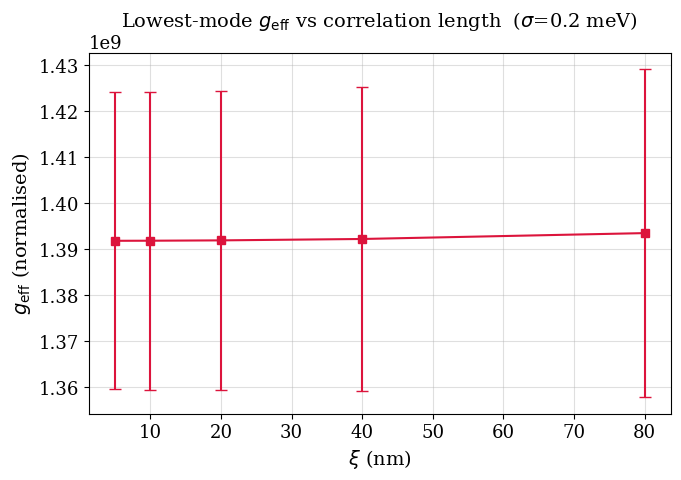

In [4]:
xis = np.array([5e-9, 10e-9, 20e-9, 40e-9, 80e-9])  # m
sigma_fixed = 0.2e-3   # eV — held constant
n_realisations = 10

xi_g_mean = np.zeros(len(xis))
xi_g_std = np.zeros(len(xis))

for xi_i, xi_val in enumerate(xis):
	vals = [
		g_eff_lowest_mode(N, L, M_lp, sigma_fixed, xi_val, hbar, g_lp=g_lp, seed=seed)
		for seed in range(n_realisations)
	]
	xi_g_mean[xi_i] = np.mean(vals)
	xi_g_std[xi_i] = np.std(vals)
	print(f"  ξ={xi_val*1e9:5.0f} nm  →  g_eff = {G_PLOT_SCALE*xi_g_mean[xi_i]:.4e} ± {G_PLOT_SCALE*xi_g_std[xi_i]:.4e}")

# Save
result_xi = np.vstack([xis, xi_g_mean, xi_g_std])
extra_xi = {
	"rows"           : ["xi_m", "g_mean_eV", "g_std_eV"],
	"sigma_eV"       : sigma_fixed,
	"N"              : N,
	"L_m"            : L,
	"M_lp_eVs2m2"   : M_lp,
	"g_lp_eVm2"      : g_lp,
	"plot_scale"     : G_PLOT_SCALE,
	"plot_units"     : "µeV·µm²",
	"n_realisations" : n_realisations,
}
stem_xi = make_sweep_stem("geff_xi", DEFAULT_PARAMS, extra={"sigma": sigma_fixed, "N": N})
save_result(result_xi, "Results/interaction_strengths", stem_xi, DEFAULT_PARAMS, extra_xi)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(xis * 1e9, G_PLOT_SCALE * xi_g_mean, yerr=G_PLOT_SCALE * xi_g_std,
			marker='s', capsize=4, linewidth=1.5,
			color=CMAP(0.65), markerfacecolor=CMAP(0.9))
ax.set_xlabel(r"$\xi$ (nm)")
ax.set_ylabel(G_PLOT_LABEL)
ax.set_title(fr"Lowest-mode $g_{{\rm eff}}$ vs correlation length  ($\sigma$={sigma_fixed*1e3:.1f} meV)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
